# Convolutional Neural Networks

# Introduction

The CIFAR-10 and CIFAR-100 are labeled subsets of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. You can download the original dataset from https://www.cs.toronto.edu/~kriz/cifar.html

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. 

We choose two classes of images from CIFAR10 to create a convolutional neural network to classify these images. 

The Keras package includes several datasets, one of them is cifar 10 so we will use `datasets.cifar10.load_data()` function to get it.


In [44]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

In [45]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Show image distribution by class
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}


## Show several images

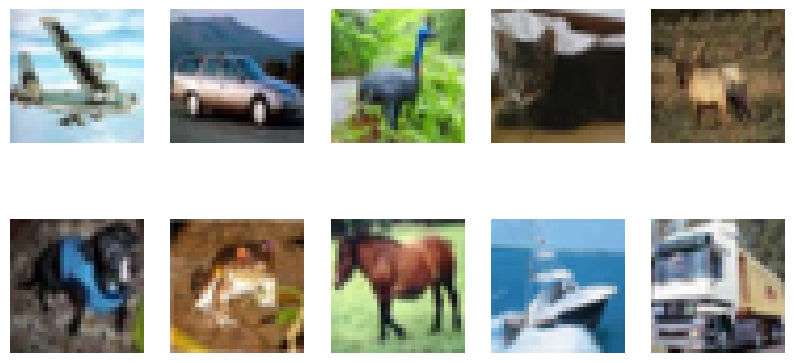

In [46]:
# Display several images
pictures = [9801, 4, 6, 9, 3, 27, 0, 7, 8, 1]
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[pictures[i]])
    ax.axis('off')
plt.show()

## Selection two classes

Select two classes and split data into to training and test. Next, normalize pixel values between 0 to 1

In [47]:
# Select two classes
i, j = 4, 7
# crea arrays que indican si son de la clase 4 i 7
train_mask = (y_train == i) | (y_train == j)
test_mask = (y_test == i) | (y_test == j)
#seleccionem
x_train, y_train = x_train[train_mask.squeeze()], y_train[train_mask.squeeze()]
x_test, y_test = x_test[test_mask.squeeze()], y_test[test_mask.squeeze()]
# converte las etiquetas en 0 i 1.
y_train = np.where(y_train == i, 0, 1)
y_test = np.where(y_test == i, 0, 1)

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

In [48]:
print(x_train.shape)
print(len(y_train))

import numpy as np
print(np.unique(y_train, return_counts=True))

(10000, 32, 32, 3)
10000
(array([0, 1]), array([5000, 5000]))


[0]


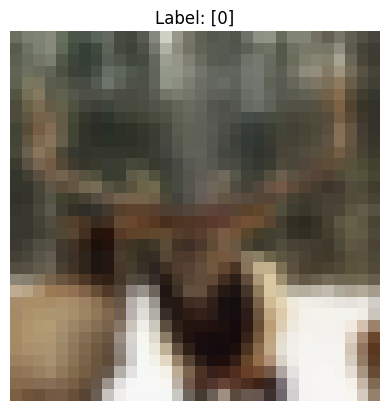

In [49]:
p = 4

print(y_test[p])  # Mostrar etiqueta

plt.imshow(x_test[p], cmap='gray')
plt.title(f"Label: {y_test[p]}")
plt.axis('off')
plt.show()

# CNN model

In [50]:
# CNN Model
model = keras.Sequential([
    keras.Input(shape = (32, 32, 3)),
    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,097 (2.61 MB)

 Trainable params: 684,097 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [52]:
history = model.fit(x_train,y_train, batch_size=128, epochs=30, validation_data=(x_test, y_test),verbose = 0)

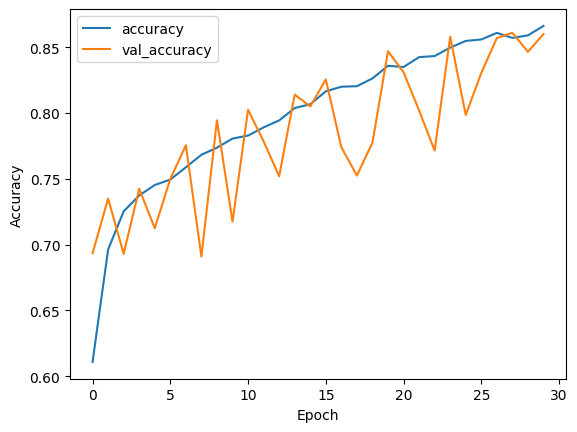

In [53]:
# Save model
model.save(f'cifar10_{i}_{j}.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Save the model

In [54]:
# Save model
model.save(f'cifar10_{i}_{j}.h5')

## ImageDataGenerator

Keras includes a number of image processing helper tools. In
particular, it includes the *ImageDataGenerator()* function, which can automatically turn image files on disk into batches of pre-processed tensors.


In [55]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters --------------------------------------------------------------
batch_size = 32
epochs = 30
data_augmentation = True
image_size = (32, 32, 3)

datagen = ImageDataGenerator()

train_generator = datagen.flow(
    x_train,
    y_train,
    batch_size=batch_size
)

batch = next(train_generator)

print(batch[0].shape)  # imágenes
print(batch[1].shape)  # etiquetas

(32, 32, 32, 3)
(32, 1)


Let’s look at the output of one of these generators: it yields batches of 32 × 32 RGB images (shape (32, 32,
32, 3)) and binary labels (shape (32)). There are 32 samples in each batch (the batch size). Note that the
generator yields these batches indefinitely: it loops endlessly over the images in the data.

In [56]:
history = model.fit(train_generator, 
                    #steps_per_epoch = len(x_train) // batch_size , 
                    epochs= epochs, 
                    validation_data = (x_test, y_test),
                    verbose = 1)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8625 - loss: 0.3175 - val_accuracy: 0.8330 - val_loss: 0.3663
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8711 - loss: 0.3038 - val_accuracy: 0.8605 - val_loss: 0.3175
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 0.2867 - val_accuracy: 0.8480 - val_loss: 0.3461
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8854 - loss: 0.2741 - val_accuracy: 0.8675 - val_loss: 0.2989
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8905 - loss: 0.2675 - val_accuracy: 0.8645 - val_loss: 0.2976
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8992 - loss: 0.2495 - val_accuracy: 0.8725 - val_loss: 0.2986
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9022 - loss: 0.2332 - val_accuracy: 0.8725 - val_loss: 0.2882
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9020 - loss: 0.2288 - val_accuracy: 0.

Let’s fit the model to the data using the generator. You have to use the fit function. It expects as its first argument a generator that will yield batches of inputs and targets indefinitely, like this one does. Because the data is being generated endlessly, the generator needs to know
how many samples to draw from the generator before declaring an epoch over.
This is the role of the steps_per_epoch argument: after having drawn steps_per_epoch batches from the
generator—that is, after having run for steps_per_epoch gradient descent steps—the fitting process will
go to the next epoch. In this case, batches are 32-samples large, so it will take 312 batches until you see
your target of 10,000 samples. When using fit function, you can pass a validation_data argument, much
as with the fit function. It’s important to note that this argument is allowed to be a data generator, but it
could also be a list of arrays. If you pass a generator as validation_data, then this generator is expected to
yield batches of validation data endlessly; thus you should also specify the validation_steps argument, which
tells the process how many batches to draw from the validation generator for evaluation. In this example, a
generator has not been used in the validation data.


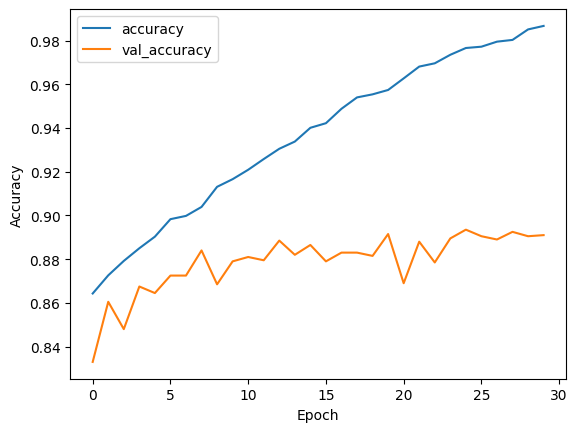

In [57]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

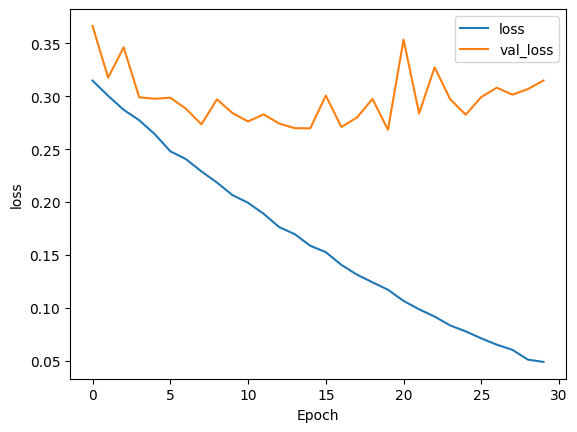

In [58]:
# Plot training history
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

These plots are characteristic of overfitting. The training accuracy increases linearly over time, until it
reaches nearly 100%, whereas the validation accuracy stalls at 71–75%. The validation loss reaches its
minimum after only five epochs and then stalls, whereas the training loss keeps decreasing linearly until it
reaches nearly 0. Because you have relatively few training samples (2,000), overfitting will be your numberone concern. You already know about a number of techniques that can help mitigate overfitting, such as
dropout and weight decay (L2 regularization). We’re now going to introduce a new one, specific to computer
vision and used almost universally when processing images with deep-learning models: data augmentation.

# Using data augmentation

Overfitting is caused by having too few samples to learn from, rendering you unable to train a model that
can generalize to new data. Given infinite data, your model would be exposed to every possible aspect of
the data distribution at hand: you would never overfit. Data augmentation takes the approach of generating
more training data from existing training samples, by augmenting the samples via a number of random
transformations that yield believable-looking images. The goal is that at training time, your model will
never see the exact same picture twice. This helps expose the model to more aspects of the data and
generalize better. In Keras, this can be done by configuring a number of random transformations to be
performed on the images read by an image_data_generator. Let’s get started with an example.
These are just a few of the options available (for more, see the Keras documentation). Let’s quickly go over
this code:
- rotation_range is a value in degrees (0–180), a range within which to randomly rotate pictures.
- width_shift and height_shift are ranges (as a fraction of total width or height) within which to randomly translate pictures vertically or horizontally.
- shear_range is for randomly applying shearing transformations.
- zoom_range is for randomly zooming inside pictures.
- horizontal_flip is for randomly flipping half the images horizontally—relevant when there are no assumptions of horizontal asymmetry (for example, real-world pictures).
- fill_mode is the strategy used for filling in newly created pixels, which can appear after a rotation or
a width/height shift

In [59]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(x_train)

# Training with data augmentation
gen = datagen.flow(x_train, y_train, batch_size=batch_size)
batch = next(gen)

print(batch[0].shape)  # imágenes
print(batch[1].shape)  # etiquetas


(32, 32, 32, 3)
(32, 1)


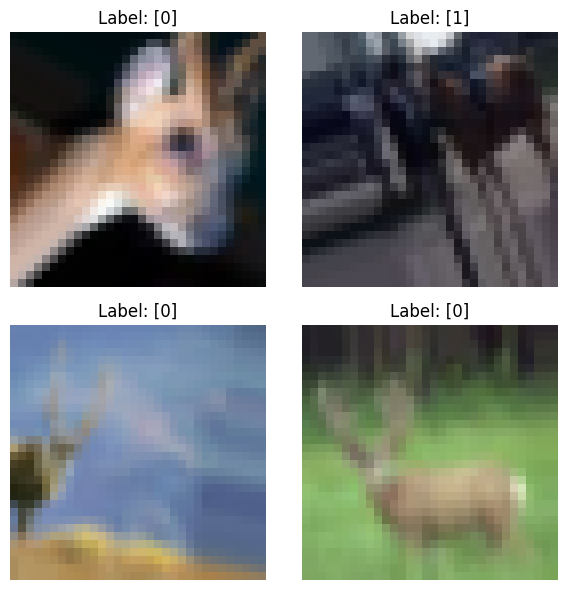

In [60]:
plt.figure(figsize=(6,6))

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0][i])
    plt.title(f"Label: {batch[1][i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [61]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])
history = model.fit(gen, 
                    #steps_per_epoch=len(x_train) // batch_size, 
                    epochs=30, 
                    validation_data=(x_test, y_test))

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7643 - loss: 0.6276 - val_accuracy: 0.8260 - val_loss: 0.3908
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - accuracy: 0.7188 - loss: 0.5671 - val_accuracy: 0.8630 - val_loss: 0.3244
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7921 - loss: 0.4435 - val_accuracy: 0.8515 - val_loss: 0.3421
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 353us/step - accuracy: 0.6875 - loss: 0.6572 - val_accuracy: 0.8715 - val_loss: 0.2958
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7977 - loss: 0.4279 - val_accuracy: 0.8570 - val_loss: 0.3329
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 339us/step - accuracy: 0.8438 - loss: 0.4016 - val_accuracy: 0.8525 - val_loss: 0.3464
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7998 - loss: 0.4216 - val_accuracy: 0.8300 - val_loss: 0.3597
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - accuracy: 0.8438 - loss: 0.3278 - val_

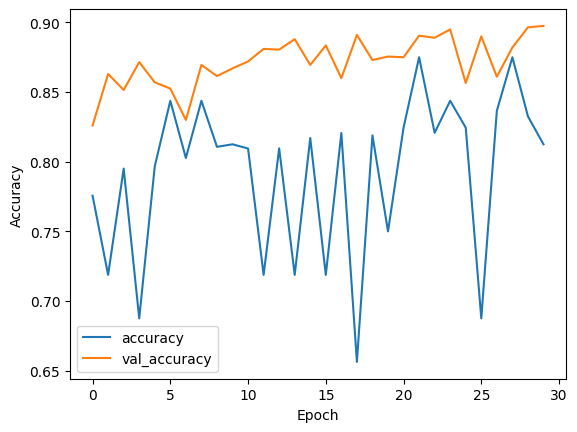

In [62]:
# Save model
model.save(f'cifar10_{i}_{j}_augm.h5')

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Using a pretrained convnet

A common and highly effective approach to deep learning on small image datasets is to use a pretrained
network. A pretrained network is a saved network that was previously trained on a large dataset, typically
on a large-scale image-classification task. If this original dataset is large enough and general enough, then
the spatial-feature hierarchy learned by the pretrained network can effectively act as a generic model of
the visual world, and hence its features can prove useful for many different computer-vision problems, even
though these new problems may involve completely different classes than those of the original task. For
instance, you might train a network on ImageNet (where classes are mostly animals and everyday objects)
and then repurpose this trained network for something as remote as identifying furniture items in images.
Such portability of learned features across different problems is a key advantage of deep learning compared to
many older, shallow-learning approaches, and it makes deep learning very effective for small-data problems.
In this case, let’s consider a large convnet trained on the ImageNet dataset (1.4 million labeled images
and 1,000 different classes). ImageNet contains many animal classes, including different species of cats and
dogs, and you can thus expect to perform well on the cats-versus-dogs classification problem. You’ll use the
VGG16 architecture, developed by Karen Simonyan and Andrew Zisserman in 2014; it’s a simple and widely
used convnet architecture for ImageNet.8 Although it’s an older model, far from the current state of the art
and somewhat heavier than many other recent models, we chose it because its architecture is similar to what
you’re already familiar with and is easy to understand without introducing any new concepts.

In [63]:
# Using pretrained VGG16 model
conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [64]:
model = keras.Sequential([
    conv_base,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [65]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Ajustar estadísticas internas (solo necesario si usas featurewise_center etc.)
datagen.fit(x_train)

# Crear generador
augmentation_generator = datagen.flow(
    x_train,
    y_train,
    batch_size=batch_size
)

In [23]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [24]:
history = model.fit(gen, steps_per_epoch=len(x_train) // batch_size, epochs=30, validation_data=(x_test, y_test))

# Save transfer learning model
model.save(f'cifar10_{i}_{j}_transferlearning.h5')

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5944 - loss: 0.6674 - val_accuracy: 0.7320 - val_loss: 0.5880
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - accuracy: 0.7188 - loss: 0.6355 - val_accuracy: 0.7350 - val_loss: 0.5879
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7116 - loss: 0.5853 - val_accuracy: 0.7605 - val_loss: 0.5357
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - accuracy: 0.7188 - loss: 0.5066 - val_accuracy: 0.7620 - val_loss: 0.5354
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7311 - loss: 0.5522 - val_accuracy: 0.7745 - val_loss: 0.5060
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.6875 - loss: 0.5347 - val_accuracy: 0.7745 - val_loss: 0.5059
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7379 - loss: 0.5318 - val_accuracy: 0.7785 - val_loss: 0.4865
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step - accuracy: 0.7500 - loss: 0.5316 - val_

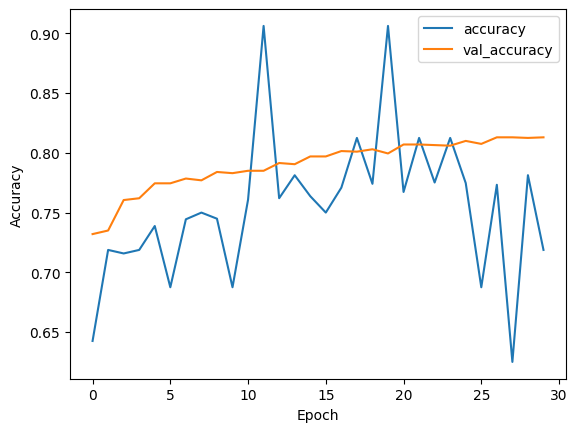

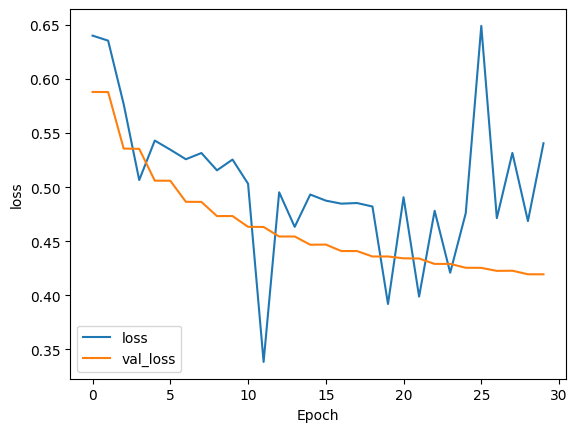

In [25]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

# Fine-tuning

Fine-tuning consists of unfreezing a few of the top layers of a frozen model base used for feature extraction,
and jointly training both the newly added part of the model (in this case, the fully connected classifier) and
these top layers. This is called fine-tuning because it slightly adjusts the more abstract representations of
the model being reused, in order to make them more relevant for the problem at hand.

In [26]:
# Fine-tuning (unfreezing some layers)
conv_base.trainable = True
for layer in conv_base.layers[:10]:
    layer.trainable = False
model.summary()
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=2e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,860 (57.14 MB)

 Trainable params: 13,110,785 (50.01 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

 Optimizer params: 131,587 (514.02 KB)

In [27]:
history = model.fit(gen, steps_per_epoch=len(x_train) // batch_size, epochs=30, validation_data=(x_test, y_test))

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7766 - loss: 0.4703 - val_accuracy: 0.8845 - val_loss: 0.2903
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.9375 - loss: 0.2680 - val_accuracy: 0.8780 - val_loss: 0.2937
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8469 - loss: 0.3511 - val_accuracy: 0.8795 - val_loss: 0.2905
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.7812 - loss: 0.4278 - val_accuracy: 0.8980 - val_loss: 0.2541
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8544 - loss: 0.3422 - val_accuracy: 0.9050 - val_loss: 0.2240
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - accuracy: 0.9375 - loss: 0.1318 - val_accuracy: 0.9025 - val_loss: 0.2288
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8639 - loss: 0.3074 - val_accuracy: 0.9080 - val_loss: 0.2231
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - accuracy: 0.8125 - loss: 0.3429 - val_

In [28]:
# Save fine-tuned model
model.save(f'cifar10_{i}_{j}_finetuningtransferlearning.h5')

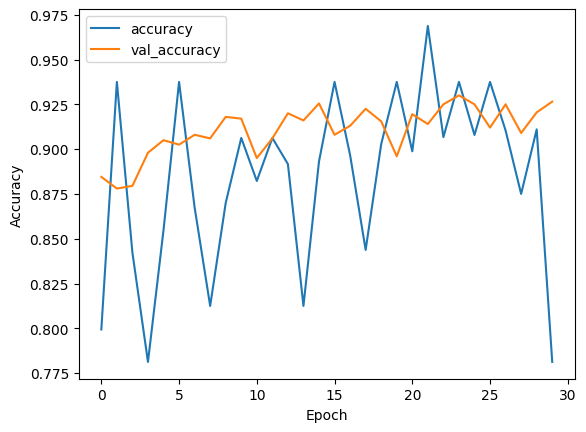

In [29]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Visualizing what convnets learn

## Visualizing intermediate activations

In [30]:
from tensorflow.keras.models import load_model

model = load_model("cifar10_4_7.h5",compile=False)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,097 (2.61 MB)

 Trainable params: 684,097 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

[0]


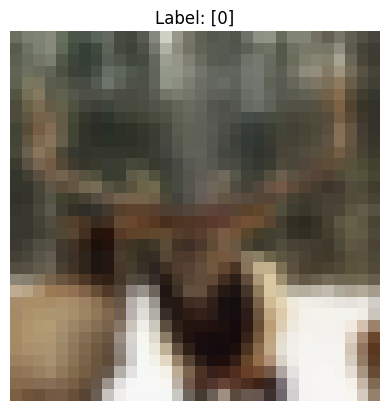

In [31]:
p = 4

print(y_test[p])

plt.imshow(x_test[p])
plt.title(f"Label: {y_test[p]}")
plt.axis("off")
plt.show()

In [32]:
# Seleccionar imagen p y normalizar
img_tensor = x_test[p] / 255.0

# Expandir dimensión para batch size = 1
img_tensor = np.expand_dims(img_tensor, axis=0)

print(img_tensor.shape)

(1, 32, 32, 3)


In [33]:
from tensorflow.keras.models import Model

# Tomar outputs de las primeras 8 capas
layer_outputs = [layer.output for layer in model.layers[:8]]

# Crear modelo de activación usando input de la primera capa
activation_model = Model(
    inputs=model.layers[0].input,
    outputs=layer_outputs
)

# Predict
activations = activation_model.predict(img_tensor)

# Primera capa de activación
first_layer_activation = activations[0]

print(first_layer_activation.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
(1, 32, 32, 32)


In [34]:
# comparar with summary of the model

def plot_channel(channel):
    # Rotar la matriz como en R (t(apply(...)))
    channel = np.flipud(channel.T)

    plt.imshow(channel, cmap='terrain')
    plt.axis('off')
    plt.gca().set_aspect('equal')
    plt.show()

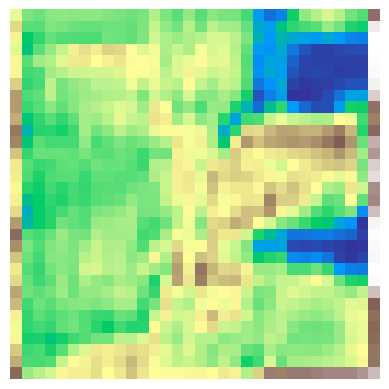

In [35]:
plot_channel(first_layer_activation[0, :, :, 0])

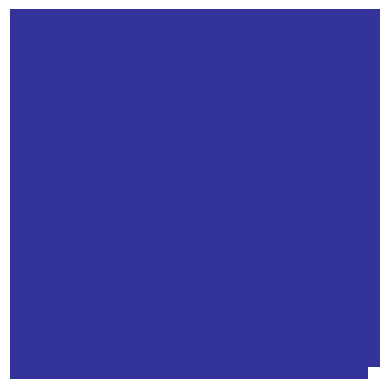

In [36]:
plot_channel(first_layer_activation[0, :, :, 4])

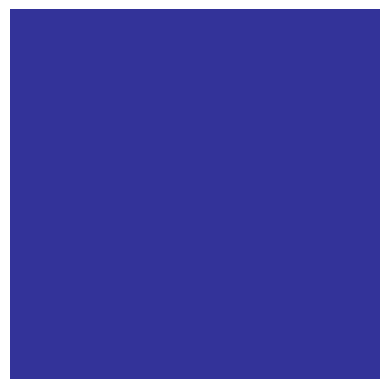

In [37]:
plot_channel(first_layer_activation[0, :, :, 14])

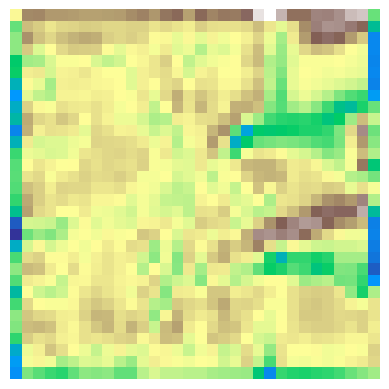

In [38]:
plot_channel(first_layer_activation[0, :, :, 19])

In [39]:
#access other layers
layer_activation = activations[5]

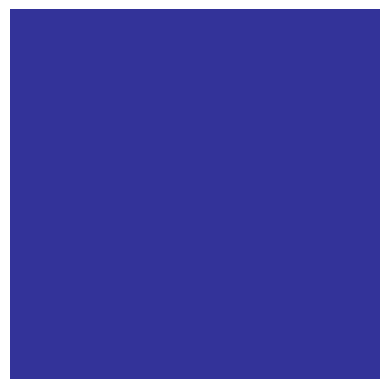

In [40]:
plot_channel(layer_activation[0, :, :, 0])

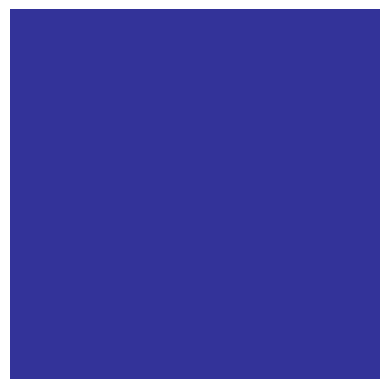

In [41]:
plot_channel(layer_activation[0, :, :, 49])

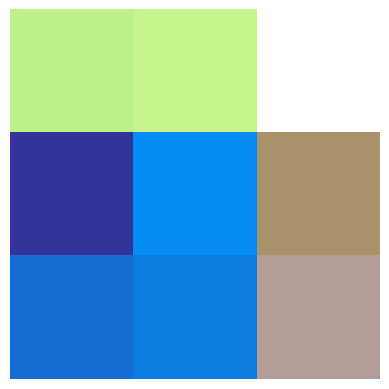

In [42]:
plot_channel(layer_activation[0, :, :, 109])